# Model evaluation metrics

Loads paired **AI total**, **human total**, and **latency** (seconds) from `data/*.csv` and reports **MAE**, **Pearson r**, and **latency** statistics per assignment, plus pooled MAE and pooled latency (Pearson is not pooled across different point scales). Later cells plot **AI vs human totals** and **residual (AI − human) vs human** to inspect calibration across score levels.

**Run with working directory `notebooks/`** (e.g. `cd notebooks` then open in Jupyter or VS Code). Run **cells in order from the top** (imports and helper functions are in the first code cell).

In [4]:
from __future__ import annotations

import csv
from pathlib import Path

import numpy as np

# Data files live at repo-root ./data/; notebook usually runs with cwd = notebooks/
DATA_DIR = Path('..') / 'data'
assert DATA_DIR.is_dir(), 'Expected ../data/ (run notebook with working directory notebooks/).'


def load_eval_csv(path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (ai_totals, human_totals, latency_s) as float arrays."""
    ai, human, lat = [], [], []
    with path.open(newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            ai.append(float(row['ai_total']))
            human.append(float(row['human_total']))
            lat.append(float(row['latency_s']))
    return np.array(ai), np.array(human), np.array(lat)


def summarize(name: str, ai: np.ndarray, human: np.ndarray, lat: np.ndarray) -> dict:
    err = ai - human
    mae = float(np.mean(np.abs(err)))
    if len(human) > 1 and np.std(human) > 0 and np.std(ai) > 0:
        r = float(np.corrcoef(human, ai)[0, 1])
    else:
        r = float('nan')
    return {
        'assignment': name,
        'n': len(ai),
        'MAE_points': mae,
        'Pearson_r': r,
        'latency_mean_s': float(np.mean(lat)),
        'latency_std_s': float(np.std(lat, ddof=1)) if len(lat) > 1 else 0.0,
        'latency_max_s': float(np.max(lat)),
    }


In [5]:
ml_ai, ml_h, ml_lat = load_eval_csv(DATA_DIR / 'ml_hw5_eval.csv')
alg_ai, alg_h, alg_lat = load_eval_csv(DATA_DIR / 'algorithms_hw9_eval.csv')

ml = summarize('ML HW5 (out of 100)', ml_ai, ml_h, ml_lat)
alg = summarize('Algorithms HW9 (out of 30)', alg_ai, alg_h, alg_lat)

pooled_ai = np.concatenate([ml_ai, alg_ai])
pooled_h = np.concatenate([ml_h, alg_h])
pooled_lat = np.concatenate([ml_lat, alg_lat])
err_p = pooled_ai - pooled_h
pooled = {
    'assignment': 'Pooled (20 grades, mixed point scales)',
    'n': len(pooled_ai),
    'MAE_points': float(np.mean(np.abs(err_p))),
    'latency_mean_s': float(np.mean(pooled_lat)),
    'latency_std_s': float(np.std(pooled_lat, ddof=1)),
    'latency_max_s': float(np.max(pooled_lat)),
}

for row in (ml, alg):
    print(row)
print(pooled)


{'assignment': 'ML HW5 (out of 100)', 'n': 10, 'MAE_points': 1.6, 'Pearson_r': 0.989732604218939, 'latency_mean_s': 31.264999999999997, 'latency_std_s': 5.9931020533795545, 'latency_max_s': 45.84}
{'assignment': 'Algorithms HW9 (out of 30)', 'n': 10, 'MAE_points': 1.7, 'Pearson_r': 0.8996002961562154, 'latency_mean_s': 29.647, 'latency_std_s': 5.051191388617584, 'latency_max_s': 41.94}
{'assignment': 'Pooled (20 grades, mixed point scales)', 'n': 20, 'MAE_points': 1.65, 'latency_mean_s': 30.455999999999996, 'latency_std_s': 5.457857107924897, 'latency_max_s': 45.84}


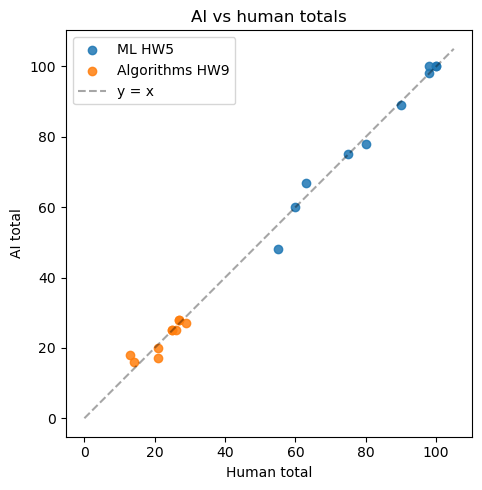

In [6]:
# Scatter: human vs AI totals (pooled)
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(ml_h, ml_ai, label='ML HW5', alpha=0.85)
    ax.scatter(alg_h, alg_ai, label='Algorithms HW9', alpha=0.85)
    lims = [0, max(pooled_h.max(), pooled_ai.max()) * 1.05]
    ax.plot(lims, lims, 'k--', alpha=0.35, label='y = x')
    ax.set_xlabel('Human total')
    ax.set_ylabel('AI total')
    ax.set_title('AI vs human totals')
    ax.legend()
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('Install matplotlib for scatter plot: pip install matplotlib')

## Residuals vs human score

**Residual** = AI total − human total (positive ⇒ the model graded **higher** than the instructor). The **dashed line is y = 0** (perfect agreement). The **orange line** is a simple **linear least-squares trend** on the residuals vs human score: a slope near **0** suggests errors are about the **same magnitude** across low vs high human scores; a **clear slope** would mean the model systematically over- or under-predicts as papers get harder or easier.

Plots are **split by assignment** because ML (100 pts) and Algorithms (30 pts) sit on different horizontal scales. With only **n = 10** per series, treat any trend as **illustrative**, not definitive.

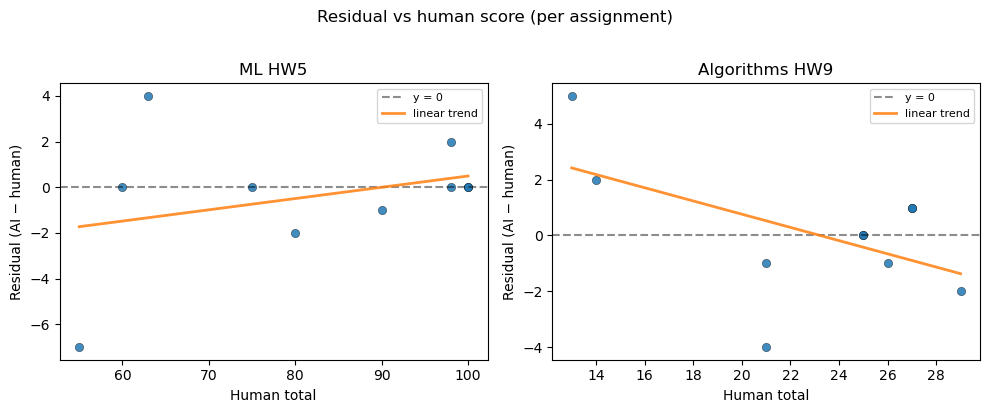

In [7]:
# Residual (AI - human) vs human total — check error vs score level
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    for ax, h, a, title in (
        (axes[0], ml_h, ml_ai, "ML HW5"),
        (axes[1], alg_h, alg_ai, "Algorithms HW9"),
    ):
        resid = a - h
        ax.scatter(h, resid, alpha=0.85, edgecolors="k", linewidths=0.3)
        ax.axhline(0.0, color="k", linestyle="--", alpha=0.45, label="y = 0")
        if len(h) >= 2 and float(np.std(h)) > 0:
            coef = np.polyfit(h, resid, 1)
            xs = np.linspace(float(h.min()), float(h.max()), 50)
            ax.plot(xs, np.polyval(coef, xs), color="C1", linewidth=2, alpha=0.85, label="linear trend")
        ax.set_xlabel("Human total")
        ax.set_ylabel("Residual (AI − human)")
        ax.set_title(title)
        ax.legend(loc="best", fontsize=8)
    plt.suptitle("Residual vs human score (per assignment)", y=1.02)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install matplotlib for plots: pip install matplotlib")